# SignalAgent Bernoulli Mixture — Results

Model:  $\pi_{\text{signal}}(a) = (1-p)\,\pi_{\text{committed}}(a \mid g^*) + p\,\delta_{a_{\text{leg}}(g^*)}$

where $a_{\text{leg}}(g^*) = \arg\max_{a \in \mathcal{A}^+(g^*)} P(g^* \mid a)$ over progress moves only. $p=0$ reduces exactly to `CommittedAgent`; only the *flavor* of the move changes as $p$ grows.

**Fixed hyperparameters:** $\beta = 3.0$, $\lambda = 0.125$.

**Fit results:**

| | value |
|---|---|
| Best $p$ | **0.375** |
| Binomial NLL | 184.4 |
| SSE (condition rates) | 0.030 |
| Sim avg signaling | 47% |
| Sim equal-to-both signaling | 64% |
| Sim equal-to-both commitment | 72% |
| Human avg signaling | 52% |
| Human equal-to-both signaling | 59% |

See `docs/SignalAgent/SignalAgent_methods.md` for full model and fit specification.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

OUT = Path('dataAnalysis/analyses/outputs/model_model/signal_agent/signal_agent_alpha_fit_beta3')
summary = json.loads((OUT / 'signal_alpha_fit_beta3_summary.json').read_text())
fit_df = pd.read_csv(OUT / 'signal_alpha_fit_beta3_average_equal.csv')
grid_df = pd.read_csv(OUT / 'signal_alpha_fit_beta3_grid.csv')
four_df = pd.read_csv(OUT / 'signal_alpha_beta3_average_equal_4measures.csv')
equal_df = pd.read_csv(OUT / 'equal_to_both_signal_joint_rl_human_4panel_summary.csv')
all_df = pd.read_csv(OUT / 'all_distance_signal_joint_rl_human_4panel_summary.csv')
human_target_df = pd.read_csv(OUT / 'human_trial_level_signaling_target.csv')
best = summary['best_by_binomial_nll']
print('score:', summary['score'])
print('best p:', best['alpha'])
print('binomial NLL:', round(best['binomial_nll'], 2))
print('SSE(rates):', round(best['sse_condition_rates'], 4))

score: mixture
best p: 0.375
binomial NLL: 184.43
SSE(rates): 0.0299


## Best fit row

In [2]:
pd.DataFrame([best]).round(4)

,alpha,sim_human_weighted_average,sim_equal_to_both,binomial_nll,sse_condition_rates,sim_closer_to_player1,human_closer_to_player1,human_equal_to_both,sim_closer_to_player2,human_closer_to_player2
0,0.375,0.4629,0.6385,184.4262,0.0299,0.3736,0.506,0.5851,0.3547,0.4524


## Human signaling target (per distance condition)

In [3]:
human_target_df.round(4)

,distanceCondition,human_n,human_signaling,human_rate
0,closer_to_player1,83,42,0.5060
1,equal_to_both,94,55,0.5851
2,closer_to_player2,84,38,0.4524


## 1. Sweep over $p$ — four measures (Average vs Equal-to-Both)

Success rate and coordination efficiency stay flat across $p$. Commitment rises modestly with $p$ (legibility makes partner's posterior crisper, reinforcing the sampled target). Signaling Move climbs roughly linearly with $p$ in both conditions, crossing both human reference levels in the $p \approx 0.3{-}0.4$ band.

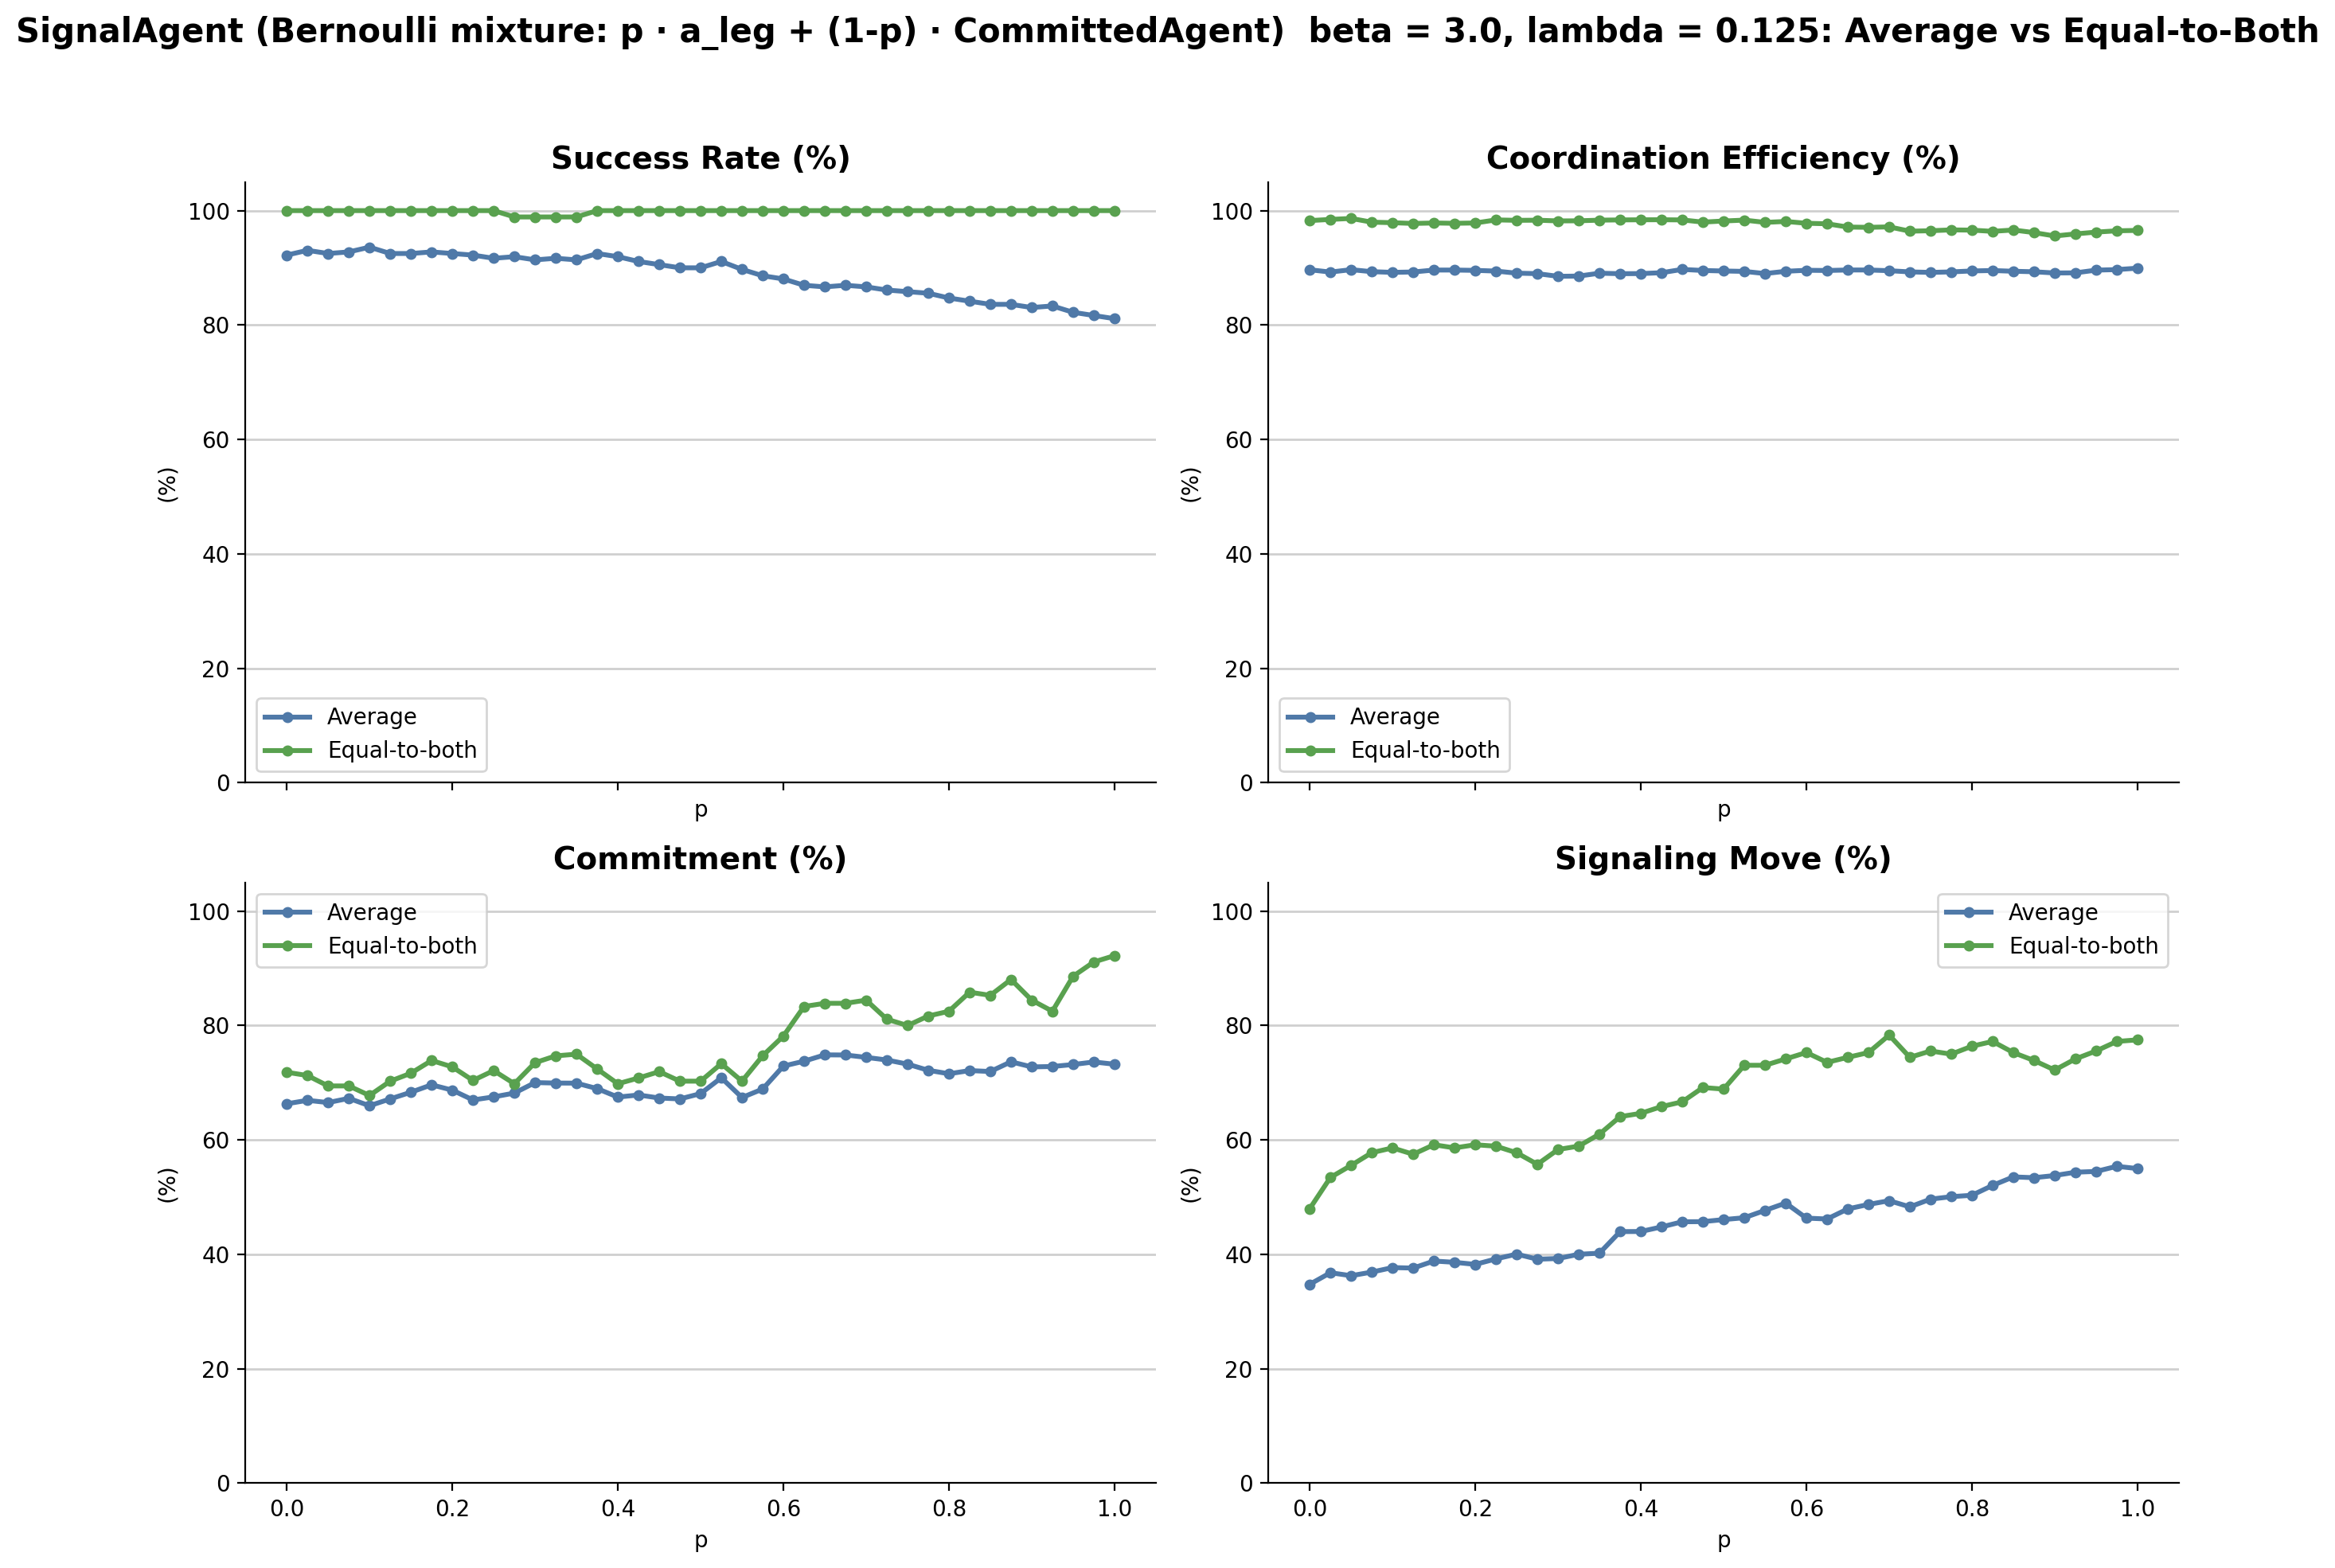

In [4]:
Image('signal_alpha_beta3_average_equal_4measures.png')

## 2. Signaling rate fit, sim vs human, with best $p$

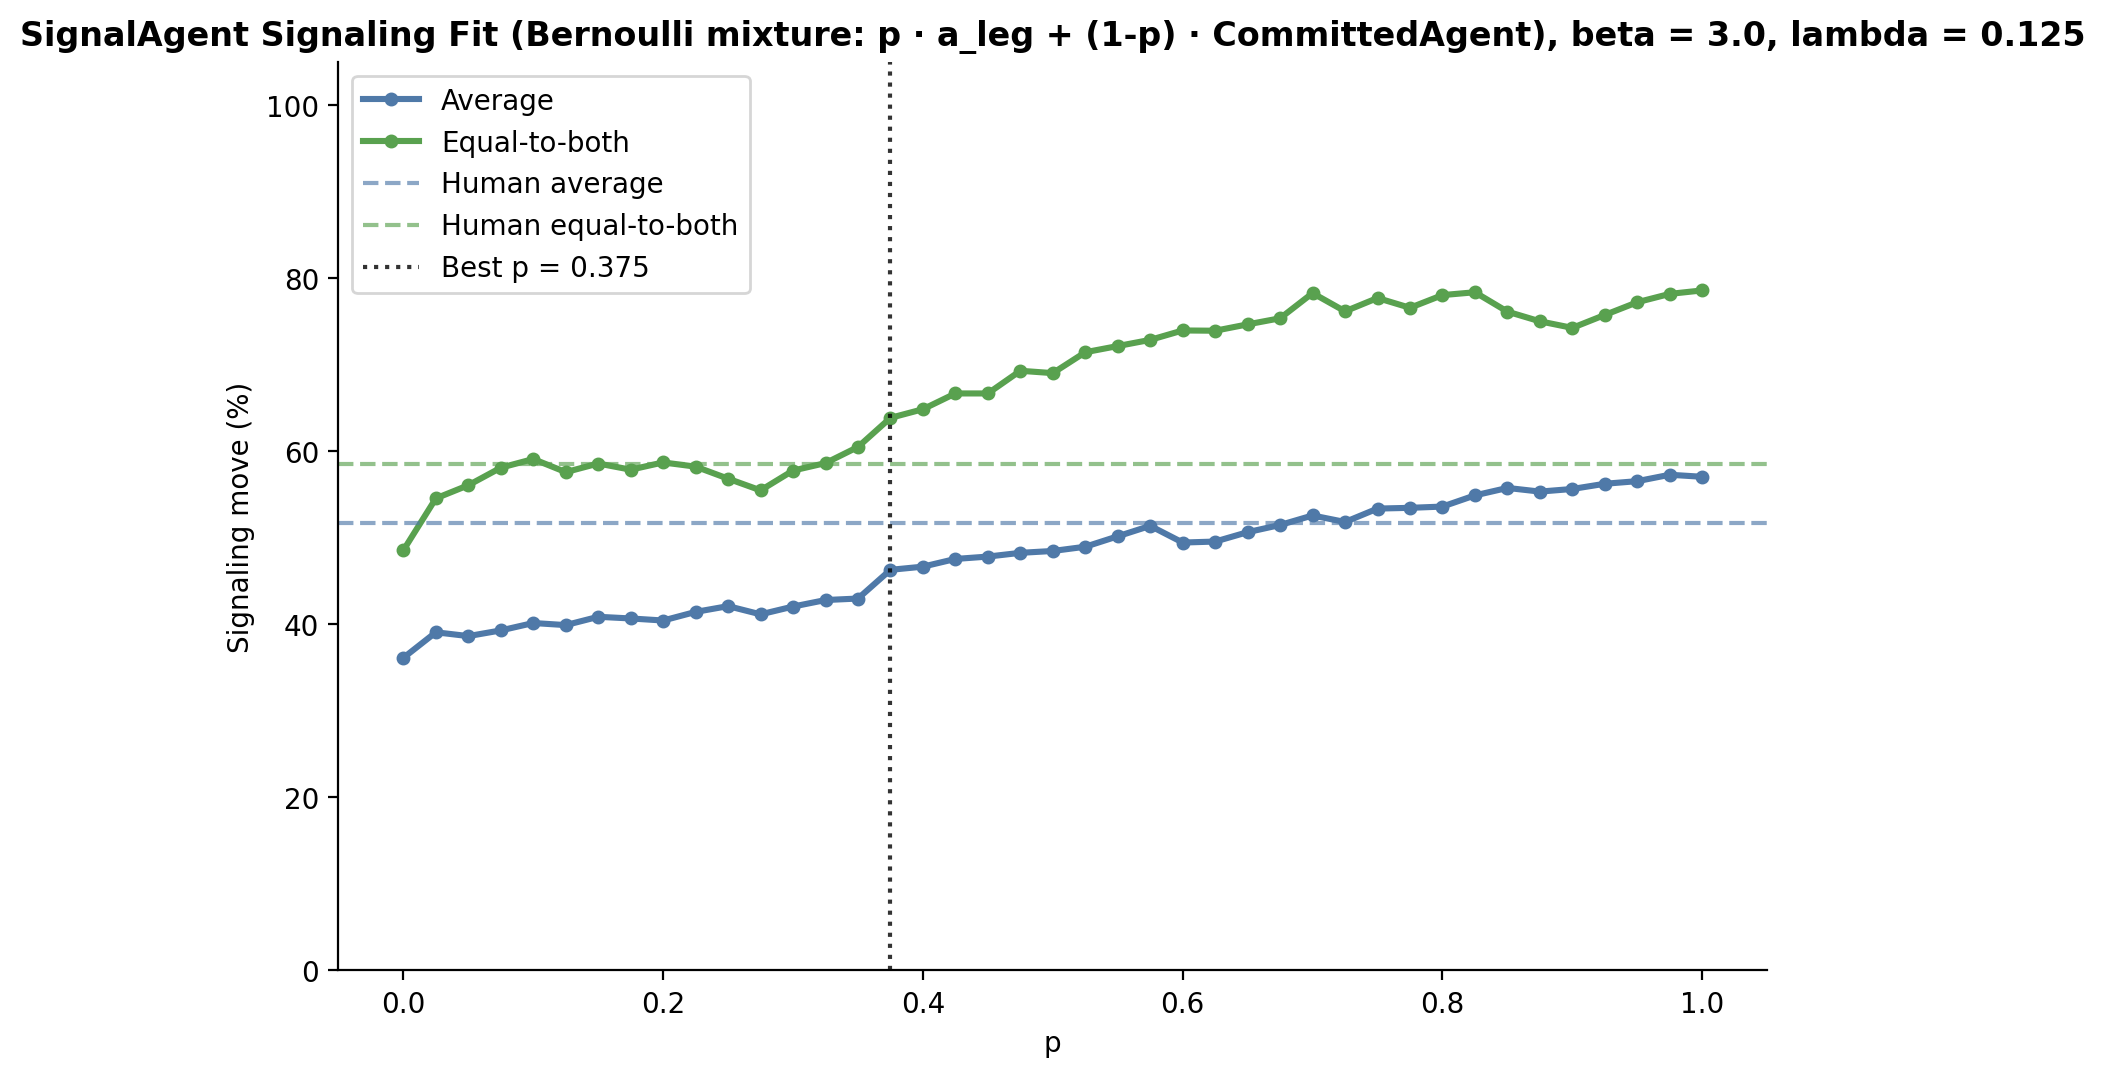

In [5]:
Image('signal_alpha_fit_beta3_average_equal.png')

## 3. Equal-to-Both — best-fit SignalAgent vs Joint-RL vs Human

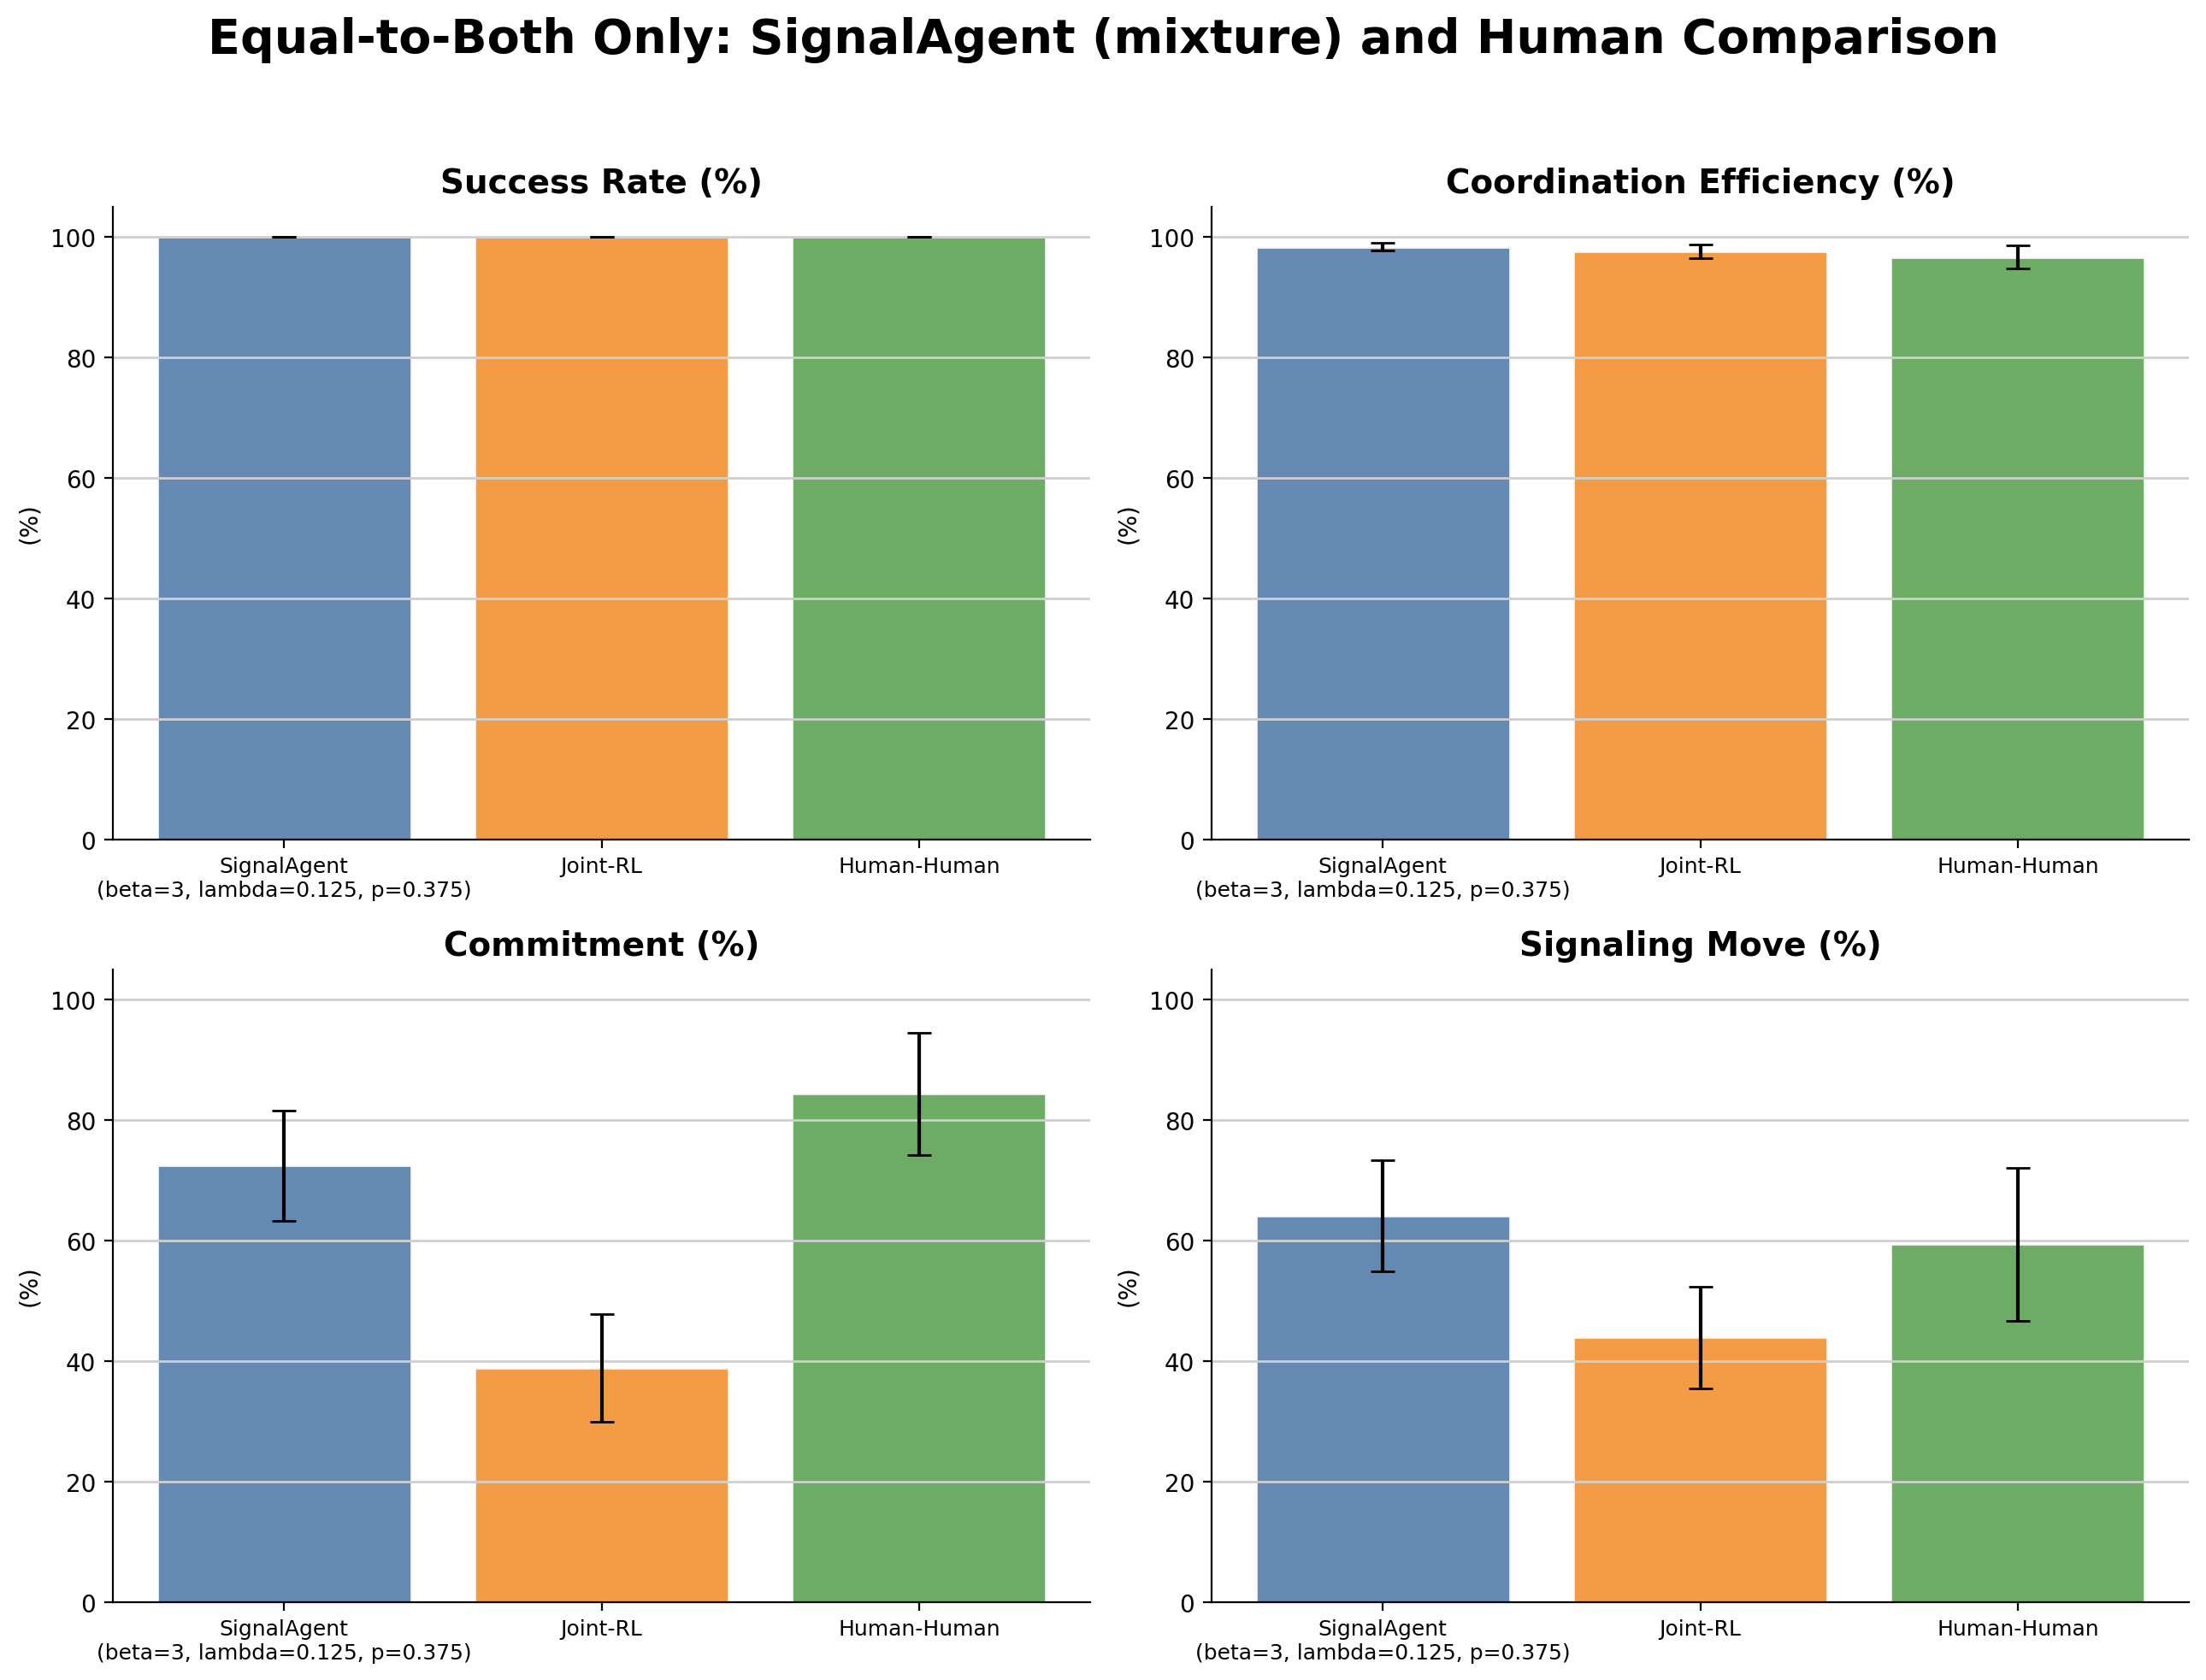

In [6]:
Image('equal_to_both_signal_beta3_best_joint_rl_human_4panel.png')

In [7]:
equal_df.round(2)

,group,metric,mean_percent,ci95_percent,n
0,"SignalAgent\n(beta=3, lambda=0.125, p=0.375)",Success Rate (%),100.00,0.00,90
1,"SignalAgent\n(beta=3, lambda=0.125, p=0.375)",Coordination Efficiency (%),98.37,0.69,58
2,"SignalAgent\n(beta=3, lambda=0.125, p=0.375)",Commitment (%),72.41,9.11,58
3,"SignalAgent\n(beta=3, lambda=0.125, p=0.375)",Signaling Move (%),64.08,9.26,58
4,Joint-RL,Success Rate (%),100.00,0.00,90
5,Joint-RL,Coordination Efficiency (%),97.57,1.15,60
6,Joint-RL,Commitment (%),38.89,8.94,60
7,Joint-RL,Signaling Move (%),43.89,8.40,60
8,Human-Human,Success Rate (%),100.00,0.00,47
9,Human-Human,Coordination Efficiency (%),96.64,1.94,32


## 4. All distance conditions (Average) — best-fit SignalAgent vs Joint-RL vs Human

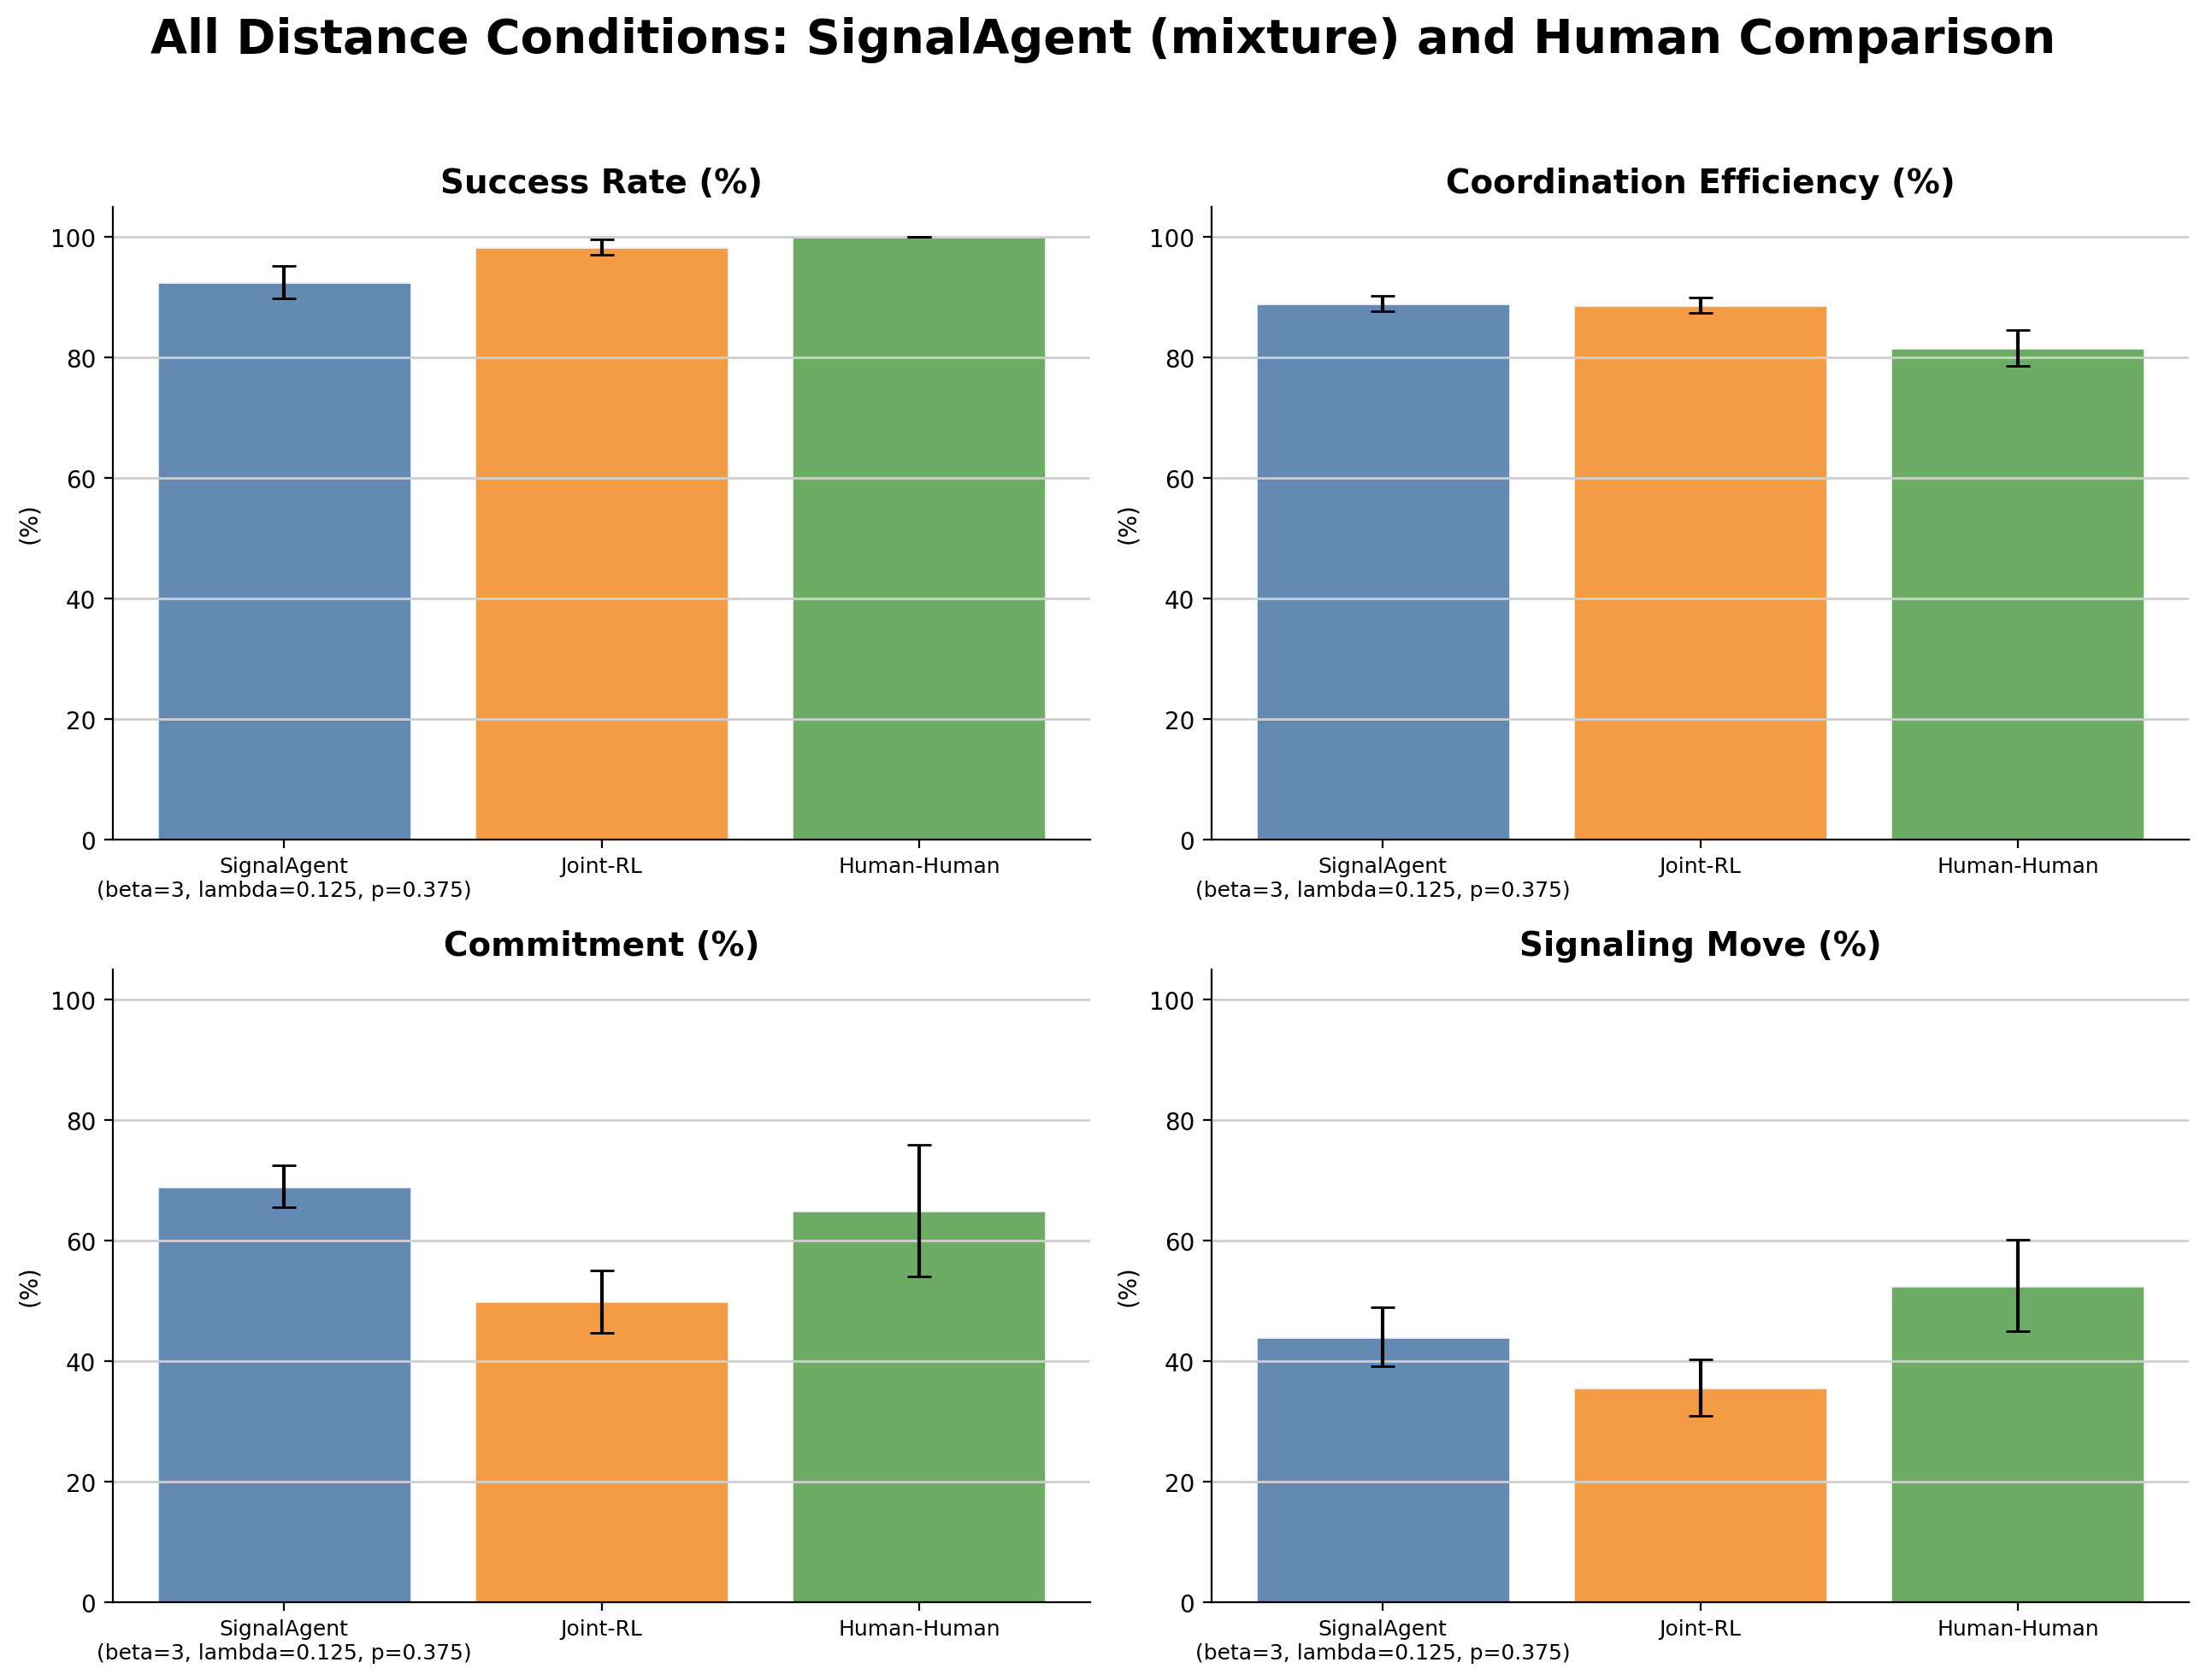

In [8]:
Image('all_distance_signal_beta3_best_joint_rl_human_4panel.png')

In [9]:
all_df.round(2)

,group,metric,mean_percent,ci95_percent,n
0,"SignalAgent\n(beta=3, lambda=0.125, p=0.375)",Success Rate (%),92.50,2.72,360
1,"SignalAgent\n(beta=3, lambda=0.125, p=0.375)",Coordination Efficiency (%),88.97,1.32,60
2,"SignalAgent\n(beta=3, lambda=0.125, p=0.375)",Commitment (%),68.98,3.45,60
3,"SignalAgent\n(beta=3, lambda=0.125, p=0.375)",Signaling Move (%),43.98,4.89,60
4,Joint-RL,Success Rate (%),98.33,1.32,360
5,Joint-RL,Coordination Efficiency (%),88.64,1.25,60
6,Joint-RL,Commitment (%),49.91,5.18,60
7,Joint-RL,Signaling Move (%),35.53,4.70,60
8,Human-Human,Success Rate (%),100.00,0.00,189
9,Human-Human,Coordination Efficiency (%),81.58,3.01,32


## Sweep table (all $p$)

Per-condition simulator signaling rates, human reference rates, binomial NLL, SSE.

In [10]:
grid_df.round(4)

,alpha,sim_human_weighted_average,sim_equal_to_both,binomial_nll,sse_condition_rates,sim_closer_to_player1,human_closer_to_player1,human_equal_to_both,sim_closer_to_player2,human_closer_to_player2
0,0.000,0.3612,0.4855,194.4499,0.0828,0.2849,0.506,0.5851,0.2976,0.4524
1,0.025,0.3907,0.5455,191.2093,0.0661,0.2931,0.506,0.5851,0.3140,0.4524
2,0.050,0.3863,0.5606,193.8439,0.0788,0.2644,0.506,0.5851,0.3118,0.4524
3,0.075,0.3929,0.5809,193.1910,0.0759,0.2824,0.506,0.5851,0.2917,0.4524
4,0.100,0.4014,0.5909,192.0664,0.0703,0.2882,0.506,0.5851,0.3012,0.4524
5,0.125,0.3990,0.5758,191.3503,0.0667,0.2941,0.506,0.5851,0.3049,0.4524
6,0.150,0.4086,0.5857,190.3282,0.0615,0.2941,0.506,0.5851,0.3235,0.4524
7,0.175,0.4067,0.5786,190.2359,0.0610,0.2941,0.506,0.5851,0.3256,0.4524
8,0.200,0.4043,0.5870,191.9417,0.0693,0.2733,0.506,0.5851,0.3294,0.4524
9,0.225,0.4143,0.5821,188.8249,0.0538,0.3081,0.506,0.5851,0.3313,0.4524


## Four-measure table across $p$

Success / Coordination Efficiency / Commitment / Signaling Move — for both Average and Equal-to-Both — at every swept $p$.

In [11]:
four_df.round(2)

,alpha,average_success_percent,average_efficiency_percent,average_efficiency_ci_low,average_efficiency_ci_high,average_commitment_percent,average_signaling_percent,average_signaling_ci_low,average_signaling_ci_high,equal_success_percent,equal_efficiency_percent,equal_efficiency_ci_low,equal_efficiency_ci_high,equal_commitment_percent,equal_signaling_percent,equal_signaling_ci_low,equal_signaling_ci_high
0,0.00,92.22,89.66,88.47,90.84,66.32,34.77,30.57,38.96,100.00,98.26,97.44,99.07,71.84,47.99,38.82,57.15
1,0.02,93.06,89.26,88.10,90.41,66.93,36.79,32.60,40.99,100.00,98.46,97.66,99.25,71.26,53.45,44.37,62.53
2,0.05,92.50,89.68,88.50,90.85,66.53,36.27,32.34,40.20,100.00,98.63,97.85,99.41,69.44,55.56,46.25,64.86
3,0.08,92.78,89.33,88.11,90.54,67.28,36.90,33.29,40.52,100.00,97.98,96.91,99.05,69.44,57.78,49.19,66.37
4,0.10,93.61,89.20,87.95,90.46,65.98,37.69,34.10,41.28,100.00,97.89,96.82,98.95,67.78,58.61,49.91,67.31
5,0.12,92.50,89.27,88.09,90.45,67.18,37.61,33.78,41.43,100.00,97.75,96.68,98.83,70.28,57.50,48.56,66.44
6,0.15,92.50,89.61,88.68,90.54,68.34,38.84,35.07,42.60,100.00,97.84,96.79,98.88,71.67,59.17,50.58,67.76
7,0.18,92.78,89.61,88.64,90.57,69.64,38.61,34.89,42.33,100.00,97.78,96.67,98.89,73.89,58.61,49.51,67.72
8,0.20,92.50,89.55,88.62,90.49,68.71,38.25,34.31,42.19,100.00,97.84,96.74,98.94,72.78,59.17,50.00,68.33
9,0.22,92.22,89.43,88.23,90.63,66.99,39.21,35.37,43.05,100.00,98.37,97.64,99.11,70.40,58.91,49.29,68.52
